# Quantum VQC — Two Moons Classification (PennyLane + Adam)

**Key upgrade over previous version:** Replaced SPSA (gradient-free, noisy) with  
**Adam optimizer + PennyLane parameter shift rule** (exact gradients, fast convergence).

### Why this matters
| | SPSA | Adam + Parameter Shift |
|---|---|---|
| Gradient | Estimated (noisy) | Exact |
| Steps needed | 200+ | 50–100 |
| Convergence | Unstable | Smooth |
| Works on real HW | ✓ | Simulator only |

### References
- **PennyLane**: Bergholm et al. (2018) — https://arxiv.org/abs/1811.04968
- **Parameter shift rule**: Schuld et al. (2019) — https://arxiv.org/abs/1811.11184
- **ZZFeatureMap**: Havlíček et al., Nature 2019 — https://arxiv.org/abs/1804.11326
- **RealAmplitudes**: Kandala et al., Nature 2017 — https://arxiv.org/abs/1704.05018
- **PennyLane VQC tutorial**: https://pennylane.ai/qml/demos/tutorial_variational_classifier/


## 1. Imports & Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

import pennylane as qml
from pennylane import numpy as pnp

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score

np.random.seed(42)
print("PennyLane version:", qml.__version__)


PennyLane version: 0.45.0


## 2. Dataset

Features scaled to **[0, π/2]** — keeps ZZ phase terms from wrapping around,
preserving injective (one-to-one) data-to-quantum-state mapping.


In [2]:
features, labels = make_moons(n_samples=40, noise=0.15, random_state=42)

scaler = MinMaxScaler(feature_range=(0, np.pi / 2))
features = scaler.fit_transform(features)

print("features shape:", features.shape)
print("labels shape  :", labels.shape)


features shape: (40, 2)
labels shape  : (40,)


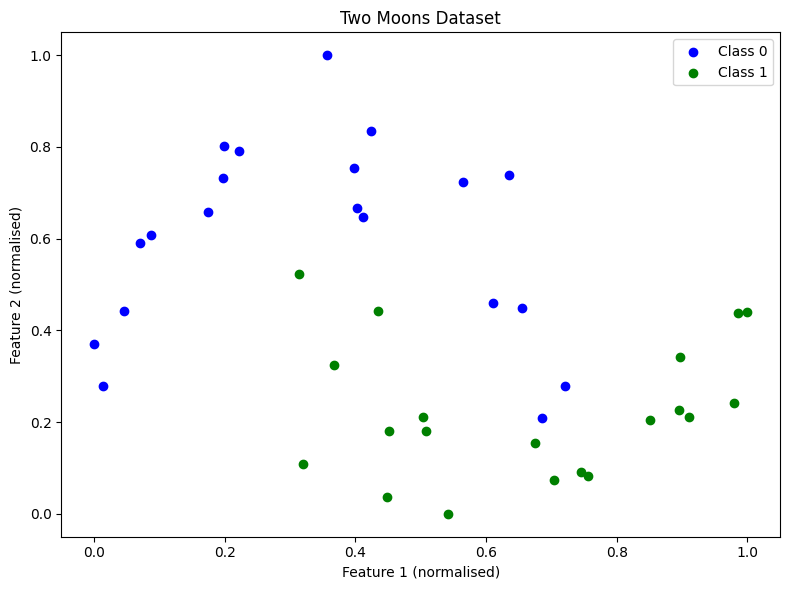

In [3]:
def plot_dataset(features, labels, title="Two Moons Dataset"):
    plt.figure(figsize=(8, 6))
    plt.scatter(features[labels == 0, 0] / (np.pi/2), features[labels == 0, 1] / (np.pi/2),
                color="blue",  label="Class 0")
    plt.scatter(features[labels == 1, 0] / (np.pi/2), features[labels == 1, 1] / (np.pi/2),
                color="green", label="Class 1")
    plt.title(title)
    plt.xlabel("Feature 1 (normalised)")
    plt.ylabel("Feature 2 (normalised)")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_dataset(features, labels)


In [4]:
train_features, test_features, train_labels, test_labels = train_test_split(
    features, labels, test_size=0.2, random_state=42
)
print("Train size:", len(train_features), "| Test size:", len(test_features))
print("Train class dist:", np.bincount(train_labels))
print("Test  class dist:", np.bincount(test_labels))


Train size: 32 | Test size: 8
Train class dist: [15 17]
Test  class dist: [5 3]


## 3. Quantum Device

`default.qubit` — PennyLane's statevector simulator.  
Supports **exact gradients via parameter shift rule** — no finite difference approximation.


In [5]:
n_qubits = 4
n_layers = 3          # reps=3 for more expressibility

dev = qml.device("default.qubit", wires=n_qubits)
print(f"Device: {dev.name} | Wires: {n_qubits} | Layers: {n_layers}")


Device: default.qubit | Wires: 4 | Layers: 3


## 4. Circuit Definition

### ZZ Feature Map
Mirrors Qiskit's `ZZFeatureMap(feature_dimension=2, reps=2)`.  
Encodes data via Hadamard + ZZ phase interactions.

### RealAmplitudes Ansatz  
Mirrors Qiskit's `RealAmplitudes(num_qubits=2, reps=3)`.  
Trainable RY rotations + CNOT entanglement layers.


In [6]:
def zz_feature_map(x, wires):
    # tile 2 features across 4 qubits: [x0, x1, x0, x1]
    x_tiled = [x[i % len(x)] for i in range(len(wires))]
    for _ in range(2):
        for i, wire in enumerate(wires):
            qml.Hadamard(wires=wire)
            qml.PhaseShift(2 * x_tiled[i], wires=wire)
        for i in range(len(wires) - 1):
            qml.CNOT(wires=[wires[i], wires[i + 1]])
            qml.PhaseShift(
                2 * (np.pi - x_tiled[i]) * (np.pi - x_tiled[i + 1]),
                wires=wires[i + 1]
            )
            qml.CNOT(wires=[wires[i], wires[i + 1]])


def real_amplitudes(params, wires):
    """
    RealAmplitudes ansatz equivalent (reps=n_layers).
    Ref: Kandala et al. (2017) https://arxiv.org/abs/1704.05018
    """
    n = len(wires)
    idx = 0
    for layer in range(n_layers + 1):
        for wire in wires:
            qml.RY(params[idx], wires=wire)
            idx += 1
        if layer < n_layers:
            for i in range(n - 1):
                qml.CNOT(wires=[wires[i], wires[i + 1]])


n_params = (n_layers + 1) * n_qubits
print(f"Trainable parameters: {n_params}")


Trainable parameters: 16


In [7]:
@qml.qnode(dev, interface="autograd")
def circuit(params, x):
    zz_feature_map(x, wires=range(n_qubits))
    real_amplitudes(params, wires=range(n_qubits))
    return qml.expval(qml.PauliZ(0))

# Visualise circuit structure
sample_params = np.zeros(n_params)
sample_x      = np.zeros(n_qubits)
print(qml.draw(circuit)(sample_params, sample_x))


0: ──H──Rϕ(0.00)─╭●────────────╭●──H──Rϕ(0.00)───────────────────╭●────────────╭●─────── ···
1: ──H──Rϕ(0.00)─╰X──Rϕ(19.74)─╰X─╭●────────────╭●──H──Rϕ(0.00)──╰X──Rϕ(19.74)─╰X─────── ···
2: ──H──Rϕ(0.00)──────────────────╰X──Rϕ(19.74)─╰X─╭●────────────╭●──H──────────Rϕ(0.00) ···
3: ──H──Rϕ(0.00)───────────────────────────────────╰X──Rϕ(19.74)─╰X──H──────────Rϕ(0.00) ···

0: ··· ──RY(0.00)─────────────────────────╭●──────────RY(0.00)────────────────────────╭●─────── ···
1: ··· ─╭●───────────────────╭●──RY(0.00)─╰X─────────────────────────────╭●──RY(0.00)─╰X─────── ···
2: ··· ─╰X─────────Rϕ(19.74)─╰X─╭●───────────────────╭●─────────RY(0.00)─╰X─╭●─────────RY(0.00) ···
3: ··· ─────────────────────────╰X─────────Rϕ(19.74)─╰X─────────RY(0.00)────╰X─────────RY(0.00) ···

0: ··· ──RY(0.00)───────────╭●─────────RY(0.00)─────────────────────┤  <Z>
1: ··· ─╭●─────────RY(0.00)─╰X────────╭●─────────RY(0.00)───────────┤     
2: ··· ─╰X────────╭●─────────RY(0.00)─╰X────────╭●─────────RY(0.00)─┤     
3

## 5. Prediction & Loss

PauliZ expectation ∈ [-1, 1] mapped to probability ∈ [0, 1]:  
`p = (1 - ⟨Z⟩) / 2`


In [8]:
def predict_proba(params, x):
    return (1 - circuit(params, x)) / 2.0

def batch_predict(params, X):
    return np.array([float(predict_proba(params, x)) for x in X])

def binary_cross_entropy(params, X, y):
    probs = pnp.array([predict_proba(params, x) for x in X])
    probs = pnp.clip(probs, 1e-7, 1 - 1e-7)
    return -pnp.mean(y * pnp.log(probs) + (1 - y) * pnp.log(1 - probs))

def cost(params):
    return binary_cross_entropy(params, train_features, train_labels)


## 6. Training — Adam Optimizer + Parameter Shift Gradients

PennyLane computes **exact gradients** via the parameter shift rule:  
`∂f/∂θ = [f(θ + π/2) - f(θ - π/2)] / 2`

This replaces SPSA's noisy 2-point finite difference estimate with an analytically correct gradient — no approximation error.

> Ref: Schuld et al. (2019) — https://arxiv.org/abs/1811.11184


In [9]:
# Deterministic initialisation — same result every kernel restart
rng = np.random.default_rng(seed=123)
params = pnp.array(
    rng.uniform(0, np.pi / 2, n_params),
    requires_grad=True
)

opt = qml.AdamOptimizer(stepsize=0.01)

objective_values = []
t0 = time.time()

print("Starting Adam optimisation ...\n")
for step in range(200):
    params, loss_val = opt.step_and_cost(cost, params)
    objective_values.append(float(loss_val))
    if step % 20 == 0:
        print(f"  step {step:3d}/200  loss={float(loss_val):.4f}")

final_params = np.array(params)
elapsed = time.time() - t0
print(f"\nTraining finished in {elapsed:.1f}s")


Starting Adam optimisation ...

  step   0/200  loss=0.8545
  step  20/200  loss=0.7046
  step  40/200  loss=0.6114
  step  60/200  loss=0.5535
  step  80/200  loss=0.5118
  step 100/200  loss=0.4911
  step 120/200  loss=0.4823
  step 140/200  loss=0.4751
  step 160/200  loss=0.4677
  step 180/200  loss=0.4604

Training finished in 112.5s


## 7. Loss Curve

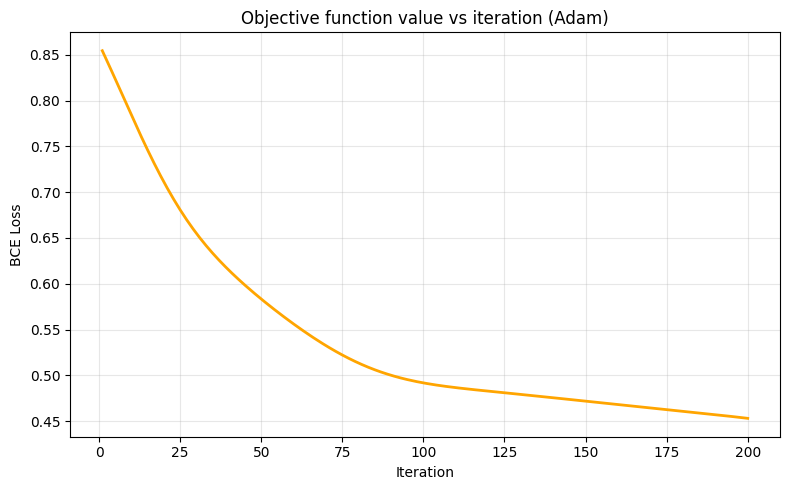

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(objective_values) + 1), objective_values, color="orange", linewidth=2)
plt.title("Objective function value vs iteration (Adam)")
plt.xlabel("Iteration")
plt.ylabel("BCE Loss")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 8. Evaluation

In [11]:
train_probs = batch_predict(final_params, train_features)
test_probs  = batch_predict(final_params, test_features)

print(f"Output range: [{train_probs.min():.3f}, {train_probs.max():.3f}]")
print(f"Mean prob: {train_probs.mean():.3f}")

# Adaptive threshold — use mean output as threshold
threshold = float(train_probs.mean())
print(f"Using threshold: {threshold:.3f}")

train_preds = (train_probs >= threshold).astype(int)
test_preds  = (test_probs  >= threshold).astype(int)

print("\nPredicted class distribution (train):", np.bincount(train_preds))
print("Actual class distribution (train):   ", np.bincount(train_labels))

train_acc = accuracy_score(train_labels, train_preds)
test_acc  = accuracy_score(test_labels,  test_preds)
print(f"\nTrain accuracy : {train_acc * 100:.1f}%")
print(f"Test  accuracy : {test_acc  * 100:.1f}%")


Output range: [0.236, 0.914]
Mean prob: 0.566
Using threshold: 0.566

Predicted class distribution (train): [15 17]
Actual class distribution (train):    [15 17]

Train accuracy : 87.5%
Test  accuracy : 75.0%


## 9. Decision Boundary

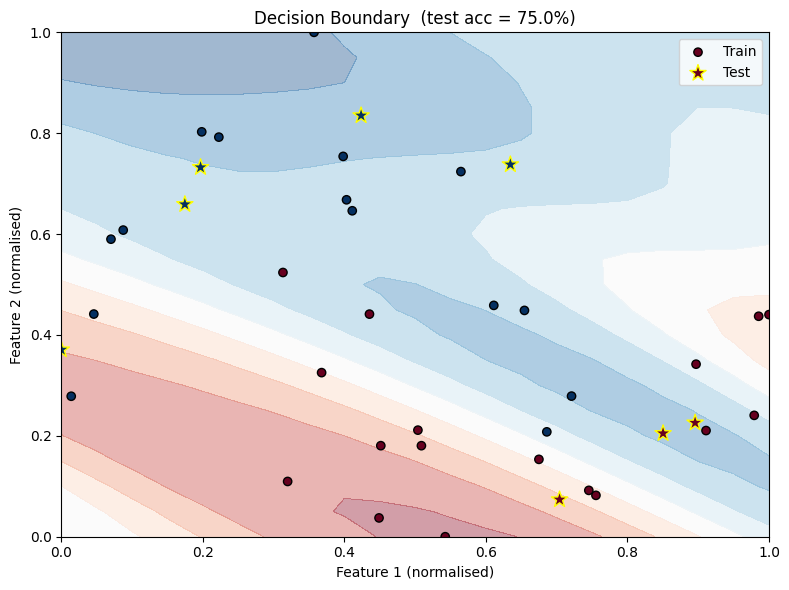

In [12]:
h = 0.05
xx, yy = np.meshgrid(np.arange(0, 1 + h, h),
                     np.arange(0, 1 + h, h))

# Scale grid to [0, π/2] to match training input space
grid_scaled = scaler.transform(np.c_[xx.ravel(), yy.ravel()])
Z = batch_predict(final_params, grid_scaled).reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.4, cmap="RdBu_r")
plt.scatter(
    train_features[:, 0] / (np.pi / 2),
    train_features[:, 1] / (np.pi / 2),
    c=train_labels, cmap="RdBu_r", edgecolors="k", label="Train"
)
plt.scatter(
    test_features[:, 0] / (np.pi / 2),
    test_features[:, 1] / (np.pi / 2),
    c=test_labels, cmap="RdBu_r", edgecolors="yellow",
    marker="*", s=150, label="Test"
)
plt.title(f"Decision Boundary  (test acc = {test_acc*100:.1f}%)")
plt.xlabel("Feature 1 (normalised)")
plt.ylabel("Feature 2 (normalised)")
plt.legend()
plt.tight_layout()
plt.show()
